# Mini caso 2 — Clustering temático con K-Means

En este notebook se prueba si los documentos del corpus pueden agruparse automáticamente según su contenido textual.

A diferencia del mini caso de clasificación, aquí no se utiliza una etiqueta objetivo. El análisis es no supervisado: el modelo agrupa documentos parecidos a partir del texto limpio.

La idea es aplicar una primera versión sencilla con:

- limpieza básica del texto;
- vectorización TF-IDF;
- clustering con K-Means;
- revisión de términos y ejemplos por cluster;
- visualización en dos dimensiones.

El objetivo no es obtener una clasificación definitiva, sino ver si aparecen grupos documentales con cierta coherencia temática.

In [13]:
from pathlib import Path

import pandas as pd

# Localización robusta de la raíz del repositorio.
# Así el notebook funciona tanto si se ejecuta desde la raíz como desde /notebooks.
current_path = Path.cwd().resolve()

if (current_path / "data").exists() and (current_path / "notebooks").exists():
    ROOT = current_path
elif (current_path.parent / "data").exists() and (current_path.parent / "notebooks").exists():
    ROOT = current_path.parent
else:
    raise FileNotFoundError("No se ha podido localizar la raíz del repositorio.")

DATA_PROCESSED = ROOT / "data" / "processed"

input_path = DATA_PROCESSED / "rtve_corpus_clean_base.csv"

df = pd.read_csv(input_path)

print(f"Archivo cargado: {input_path.relative_to(ROOT)}")
print(f"Dimensiones: {df.shape}")

display(df.head())

Archivo cargado: [PROJECT_ROOT]/data/processed/rtve_corpus_clean_base.csv
Dimensiones: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,...,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,3,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_20_de_febrero_de_1982.pdf,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiales, aunque plagado de controversias por la interpretación y selección de testimonios, especialmente e...",C/SG/2820/20-02-82 DTOR. Vista oral 2/81,"C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.\n\n- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones sig...","C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.\n\n- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones sig...",...,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,4,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_22_de_febrero_de_1982.pdf,"Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Supremo de Justicia Militar, donde se analizaron declaraciones y diligencias relacionadas con hechos militares y posibles conspiraciones. A lo largo de l...",C/SG/2896/22-02-82 Vista oral 2/81 Consejo Supremo de Justicia Militar,"C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.\n\n- A las 10'05 se inicia la sesión, con una presencia menor de periodistas y familiares.\n\n- El Ministerio Fiscal solicita ...","C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.\n\n- A las 10'05 se inicia la sesión, con una presencia menor de periodistas y familiares.\n\n- El Ministerio Fiscal solicita ...",...,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,5,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_militar_24_de_febrero_de_1982.pdf,"Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, marcadas por polémicas en torno a la cobertura mediática del Diario 16 y la actitud de los procesados, defensores y fuerzas m...",C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,"C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82\n\nAntes de la hora de comienzo oficial de la Vista las comisiones militares y familias comentan el artículo de Diario 16 ""A...","C/SG/2992

## 1. Selección de datos

En este mini caso se trabaja con los 167 documentos del corpus limpio. Se utiliza `text_clean_base` como texto principal y se conserva `doc_id` para mantener la trazabilidad de cada documento.

El análisis es no supervisado: no se utiliza ninguna etiqueta como variable objetivo. La columna `moncloa_section` se mantiene únicamente como metadato auxiliar para interpretar los resultados al final, pero no se usará para construir los clusters.

También se conserva `title`, ya que permite revisar manualmente ejemplos de documentos dentro de cada grupo.

In [14]:
df_text = df[
    [
        "doc_id",
        "title",
        "text_clean_base",
        "text_clean_length_words",
        "moncloa_section",
    ]
].copy()

df_text = df_text[
    df_text["text_clean_base"].notna()
    & (df_text["text_clean_length_words"] >= 50)
].copy()

print("Documentos seleccionados para clustering:")
print(df_text.shape)

print("\nResumen de longitud de los textos seleccionados:")
display(df_text["text_clean_length_words"].describe().to_frame().T)

display(
    df_text[
        ["doc_id", "title", "text_clean_length_words", "moncloa_section"]
    ].head()
)

Documentos seleccionados para clustering:
(167, 5)

Resumen de longitud de los textos seleccionados:


,count,mean,std,min,25%,50%,75%,max
text_clean_length_words,167.0,2075.443114,7731.242472,72.0,238.5,579.0,1771.5,95293.0


,doc_id,title,text_clean_length_words,moncloa_section
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,640,defensa
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,1018,defensa
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,1347,defensa
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,1826,defensa
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,1740,defensa


## 2. Preprocesamiento textual

Antes de vectorizar los documentos se aplica una limpieza textual sencilla orientada al clustering.

El objetivo no es modificar el significado del documento, sino reducir ruido básico que puede dominar el cálculo de similitud: mayúsculas, signos sueltos, números aislados, palabras vacías y términos demasiado cortos.

En esta primera versión no se aplica lematización, porque añadiría dependencia de modelos lingüísticos externos y complicaría el notebook. Si más adelante fuera necesario, podría incorporarse como mejora.

In [15]:
import re

stopwords_es = {
    "a", "al", "algo", "ante", "antes", "como", "con", "contra", "cual",
    "cuando", "de", "del", "desde", "donde", "durante", "e", "el", "ella",
    "ellas", "ellos", "en", "entre", "era", "eran", "es", "esa", "esas",
    "ese", "eso", "esos", "esta", "estaba", "estado", "estan", "estar",
    "este", "esto", "estos", "fue", "fueron", "ha", "habia", "han", "hasta",
    "hay", "la", "las", "le", "les", "lo", "los", "mas", "más", "me", "mi", "muy",
    "no", "nos", "o", "para", "pero", "por", "porque", "que", "se", "sin",
    "sobre", "son", "su", "sus", "tambien", "te", "tiene", "un", "una",
    "unas", "uno", "unos", "y", "ya"
}

stopwords_en = {
    "the", "and", "of", "to", "in", "that", "is", "was", "for", "on",
    "with", "as", "by", "at", "from", "it", "this", "be", "or", "an",
    "you", "your", "have", "has", "had", "are", "were", "they", "their",
    "we", "he", "his", "she", "her", "them"
}

# Lista ajustada después de revisar los términos que dominaban los clusters.
# Incluye palabras administrativas, restos de OCR y términos demasiado generales.
stopwords_custom = {
    "documento", "documentos", "pagina", "paginas", "pdf", "rtve",
    "img", "jpeg", "dtor",

    "excmo", "núm", "num", "ref", "señor",
    "dios", "guarde", "muchos", "años",

    "todos", "todo", "parte", "otra", "otro", "otros", "otras",
    "puede", "ser", "está", "esta", "mismo", "misma",

    "don", "fecha", "asunto", "asuntos", "nota", "informativa",
    "sesion", "sesión", "desarrollo", "incidencias",

    "general", "jefe", "presidente", "ministro", "consejo",
    "tribunal", "sala", "capitán", "coronel", "teniente",
    "tcol", "gral",

    "gobierno", "militar", "militares"
}

stopwords = stopwords_es | stopwords_en | stopwords_custom


def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    tokens = text.split()

    tokens_clean = [
        token
        for token in tokens
        if len(token) >= 3 and token not in stopwords
    ]

    return " ".join(tokens_clean)


df_text["text_processed"] = df_text["text_clean_base"].apply(preprocess_text)

print("Preprocesamiento aplicado.")
print("Ejemplo antes:")
print(df_text["text_clean_base"].iloc[0][:500])

print("\nEjemplo después:")
print(df_text["text_processed"].iloc[0][:500])

Preprocesamiento aplicado.
Ejemplo antes:
C/SG/2820/20-02-82
DTOR.

NOTA INFORMATIVA

ASUNTO: Vista oral 2/81

1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82

- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.

- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:

. Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte. Gral. Lluch).

. Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte. Gral. Esquivias).

. 1a, 2a, 3a y 4a del Teniente Coronel TEJERO.

. Ca

Ejemplo después:
vista oral correspondiente solo tenido lugar mañana empezó horas tenido lugar petición fiscal declaraciones siguientes parcial luis arana lorite ayte lluch parcial manuel miler hidalgo ayte esquivias tejero careo tejero carres descanso horas horas careo tejero gomez iglesias certificación congreso lavilla certificación situación tejero diego ibañez ingles certificación entonces gobernador civil valencia josé maría fernández rio fernánd

### Lectura del bloque

El preprocesamiento aplicado es deliberadamente sencillo. Se parte de `text_clean_base` y se genera una nueva columna, `text_processed`, pensada específicamente para la vectorización textual del clustering.

La limpieza convierte el texto a minúsculas, elimina URLs, signos no alfabéticos, números aislados, palabras vacías frecuentes y términos demasiado cortos. Con ello se evita que palabras funcionales como `de`, `el`, `que`, `la`, `the` o `and` dominen la representación TF-IDF.

No se aplica lematización en esta primera versión. La decisión se toma para mantener el notebook simple, reproducible y fácil de defender. Si los resultados posteriores muestran clusters poco interpretables, la lematización podría incorporarse como mejora futura.

## 3. Vectorización TF-IDF

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(df_text["text_processed"])

print("Matriz TF-IDF creada:")
print(X_tfidf.shape)

print("\nNúmero de términos en el vocabulario:")
print(len(vectorizer.get_feature_names_out()))

print("\nPrimeros términos del vocabulario:")
print(vectorizer.get_feature_names_out()[:30])

Matriz TF-IDF creada:
(167, 3000)

Número de términos en el vocabulario:
3000

Primeros términos del vocabulario:
['abad' 'abad gutierrez' 'abajo' 'abandonado' 'abandonar' 'abierto'
 'abogado' 'abogado defensor' 'abogados' 'abogados defensores' 'abrazo'
 'abril' 'absolución' 'absoluta' 'absoluta normalidad' 'absolutamente'
 'absoluto' 'acaba' 'acaban' 'acabar' 'academia' 'academia tráfico'
 'acaecidos' 'acaso' 'acceso' 'accion' 'acciones' 'acciones protesta'
 'acción' 'acepta']


### Lectura del bloque

La vectorización TF-IDF transforma cada documento en una representación numérica basada en la importancia relativa de sus términos dentro del corpus.

En esta versión se limita el vocabulario a un máximo de 3000 términos, se eliminan términos que aparecen en un solo documento y también aquellos demasiado frecuentes en el conjunto del corpus. Además, se incluyen unigramas y bigramas para conservar expresiones relevantes como `guardia civil`, `teniente coronel` o `abogado defensor`.

Esta representación será la entrada del algoritmo de clustering. No se utiliza ninguna etiqueta institucional para crear la matriz, por lo que el análisis sigue siendo no supervisado.

## 4. Selección del número de clusters

Antes de entrenar un modelo final de K-Means, se prueban varios valores de `k`.

Como no existe una etiqueta real contra la que comparar, la evaluación se basa en métricas internas y en la interpretabilidad posterior de los grupos. El objetivo no es encontrar un valor “perfecto”, sino seleccionar un número de clusters razonable para explorar el corpus.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_tfidf)
    
    silhouette = silhouette_score(
        X_tfidf,
        labels,
        metric="cosine"
    )
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index().tolist()
    
    results.append({
        "k": k,
        "silhouette_cosine": silhouette,
        "inertia": model.inertia_,
        "cluster_sizes": cluster_sizes
    })

df_k_results = pd.DataFrame(results)

display(df_k_results)

,k,silhouette_cosine,inertia,cluster_sizes
0,2,0.050408,146.414800,"[119, 48]"
1,3,0.071176,142.011492,"[91, 48, 28]"
2,4,0.082826,138.318122,"[16, 48, 26, 77]"
3,5,0.082478,136.522745,"[48, 66, 6, 19, 28]"
4,6,0.059026,133.699682,"[20, 26, 9, 57, 26, 29]"
5,7,0.076782,131.562488,"[8, 18, 25, 44, 9, 22, 41]"
6,8,0.083508,129.357102,"[15, 42, 63, 10, 8, 9, 9, 11]"


### Lectura del bloque

Se prueban varios valores de `k` para no elegir el número de clusters totalmente a mano.

Los valores de Silhouette son bastante parecidos entre varias opciones. Aunque `k = 8` obtiene el valor más alto, la mejora respecto a `k = 5` es pequeña. Además, con ocho clusters el resultado queda más fragmentado y es más difícil de interpretar.

Por eso se mantiene `k = 5` como una solución intermedia: no es necesariamente el valor “óptimo”, pero permite obtener grupos manejables y fáciles de revisar.

## 5. Entrenamiento final del modelo de clustering

In [18]:
# Entrenamiento final con el número de clusters seleccionado
k_final = 5

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

df_text["cluster"] = kmeans_final.fit_predict(X_tfidf)

cluster_summary = (
    df_text["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="n_documentos")
)

cluster_summary["porcentaje"] = (
    cluster_summary["n_documentos"] / len(df_text) * 100
).round(2)

display(cluster_summary)

,cluster,n_documentos,porcentaje
0,0,48,28.74
1,1,66,39.52
2,2,6,3.59
3,3,19,11.38
4,4,28,16.77


### Lectura del bloque

Con `k = 5`, el corpus queda dividido en cinco grupos de tamaño desigual. Esta distribución es razonable en un corpus documental heterogéneo, donde algunos bloques documentales son amplios y otros corresponden a subconjuntos más específicos.

El cluster 1 es el más grande, con 66 documentos, seguido del cluster 0 con 48 documentos y del cluster 4 con 28 documentos. El cluster 3 contiene 19 documentos y el cluster 2 es el más pequeño, con 6 documentos.

La existencia de un cluster pequeño no invalida el resultado, pero indica que debe interpretarse con cautela. Puede representar un subconjunto documental muy específico, especialmente vinculado a documentación exterior, diplomática o institucional.

A partir de este punto, la calidad del clustering no debe evaluarse solo mediante una métrica interna. Al tratarse de un problema no supervisado, la interpretación de términos representativos y ejemplos documentales es necesaria para valorar si los grupos tienen sentido.

## 6. Interpretación de clusters

In [19]:
terms = vectorizer.get_feature_names_out()

cluster_terms = []

for cluster_id in range(k_final):
    center = kmeans_final.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-15:][::-1]
    top_terms = [terms[i] for i in top_indices]
    
    cluster_terms.append({
        "cluster": cluster_id,
        "n_documentos": int(cluster_summary.loc[
            cluster_summary["cluster"] == cluster_id,
            "n_documentos"
        ].iloc[0]),
        "terminos_representativos": ", ".join(top_terms)
    })

df_cluster_terms = pd.DataFrame(cluster_terms)

display(df_cluster_terms)

,cluster,n_documentos,terminos_representativos
0,0,48,"armada, tejero, fiscal, congreso, defensor, civil, guardia, guardia civil, declaración, interrogatorio, defensores, milans, comandante, órdenes, rey"
1,1,66,"golpe, españa, civil, situación, fas, madrid, congreso, partido, grupo, miembros, interior, fuerzas, prensa, guardia, tejero"
2,2,6,"die, majestad, europa, mensaje, exteriores, federal, pueblo, cámara, juan carlos, llorca, embajador, carlos, agradezco, mis, isabel"
3,3,19,"spain, spanish, haig, democracy, washington, democratic, reagan, espanha, america, unidos, estados unidos, people, estados, states, united"
4,4,28,"justicia, supremo, togado, consejero, consejero togado, defensa, causa, madrid, procesamiento, reunido justicia, supremo justicia, junio, especial, togado juez, exmo"


In [20]:
pd.set_option("display.max_colwidth", 300)

df_cluster_terms

,cluster,n_documentos,terminos_representativos
0,0,48,"armada, tejero, fiscal, congreso, defensor, civil, guardia, guardia civil, declaración, interrogatorio, defensores, milans, comandante, órdenes, rey"
1,1,66,"golpe, españa, civil, situación, fas, madrid, congreso, partido, grupo, miembros, interior, fuerzas, prensa, guardia, tejero"
2,2,6,"die, majestad, europa, mensaje, exteriores, federal, pueblo, cámara, juan carlos, llorca, embajador, carlos, agradezco, mis, isabel"
3,3,19,"spain, spanish, haig, democracy, washington, democratic, reagan, espanha, america, unidos, estados unidos, people, estados, states, united"
4,4,28,"justicia, supremo, togado, consejero, consejero togado, defensa, causa, madrid, procesamiento, reunido justicia, supremo justicia, junio, especial, togado juez, exmo"


In [21]:
for cluster_id in range(k_final):
    print("\n" + "="*80)
    print(f"CLUSTER {cluster_id}")
    print("="*80)
    
    ejemplos = (
        df_text[df_text["cluster"] == cluster_id]
        [["doc_id", "title", "text_clean_length_words", "moncloa_section"]]
        .sort_values("text_clean_length_words", ascending=False)
        .head(5)
    )
    
    display(ejemplos)


CLUSTER 0


,doc_id,title,text_clean_length_words,moncloa_section
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de febrero.,8965,defensa
49,rtve_1811,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de mayo de 1982).,4184,defensa
73,rtve_1787,"""Nota """"Campaña contra S.M."""" (sin firma).""",4105,interior
22,rtve_1838,Vista oral 2/81 del Consejo Supremo de Justicia Militar (30 de marzo de 1982).,3827,defensa
21,rtve_1839,Vista oral 2/81 del Consejo Supremo de Justicia Militar (29 de marzo de 1982).,3135,defensa



CLUSTER 1


,doc_id,title,text_clean_length_words,moncloa_section
161,rtve_1699,Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.,95293,interior
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del estado de situación (23 de febrero de 1981).,19857,interior
63,rtve_1797,Investigación y declaraciones personal AOME por JDDI (9 de abril de 1981).,14485,defensa
76,rtve_1784,Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981).,13639,interior
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo del juicio",11080,interior



CLUSTER 2


,doc_id,title,text_clean_length_words,moncloa_section
86,rtve_1774,D.29._AGA-83-09301_exp._5,301,exteriores
87,rtve_1773,D.28._AGA-83-09301_exp._5,237,exteriores
85,rtve_1775,D.30._AGA-83-09301_exp._5,228,exteriores
89,rtve_1771,D.26._AGA-83-09301_exp._5,149,exteriores
92,rtve_1768,D.23._AGA-83-07633_exp._4,130,exteriores



CLUSTER 3


,doc_id,title,text_clean_length_words,moncloa_section
84,rtve_1776,D.31._AGA-83-09301_exp._5,1926,exteriores
109,rtve_1751,D.8._AGMAE_R39017_Exp._4,651,exteriores
102,rtve_1758,D.14._AGMAE_R39017_Exp._4,650,exteriores
95,rtve_1765,D.21._AGA-83-07633_exp._4,423,exteriores
101,rtve_1759,D.15._AGMAE_R40201_Exp._215,367,exteriores



CLUSTER 4


,doc_id,title,text_clean_length_words,moncloa_section
119,rtve_1741,SECRETO: información sobre circunstancias de la detención de Milans del Bosch.,1218,defensa
118,rtve_1742,SECRETO: distribución de los procesados por la Causa 2/81 en diferentes Unidades militares durante el juicio.,761,defensa
124,rtve_1736,SECRETO: informe jurídico sobre recurso contra la desestimación de la recusación del Ministro de Defensa.,663,defensa
144,rtve_1716,Revisión de la sentencia dictada en la causa 2/81 del CSJM (19 de octubre de 1987).,570,defensa
141,rtve_1719,RESERVADO: Informe de Asesoría Jurídica General sobre su situación administrativa del Cap. Sánchez Valiente.,494,defensa


### Lectura del bloque

La revisión de ejemplos permite comprobar que los clusters no se explican únicamente por términos aislados, sino que agrupan documentos con cierta coherencia documental.

El cluster 0 agrupa principalmente documentos relacionados con la vista oral, Tejero, declaraciones, defensores y documentación judicial-militar. El cluster 1 reúne documentos más generales sobre el contexto del golpe, la situación interior, el Congreso, la Guardia Civil, las FAS y la reacción institucional o política. El cluster 2 es un grupo pequeño y específico, vinculado a documentación exterior, Casa Real y mensajes institucionales. El cluster 3 recoge documentos de Exteriores con una dimensión internacional más marcada, incluyendo referencias a prensa extranjera, democracia, Estados Unidos o actores internacionales. El cluster 4 se asocia a documentación procesal y de justicia militar, especialmente vinculada al Consejo Supremo, causas, consejeros togados y procedimientos judiciales.

Esta revisión confirma que la agrupación obtenida es interpretable y aporta una primera segmentación temática del corpus. Aun así, los clusters no deben entenderse como categorías cerradas: al tratarse de un método no supervisado, la interpretación depende de la combinación entre métricas internas, términos representativos y revisión cualitativa de documentos.

In [22]:
cluster_labels = {
    0: "Vista oral, Tejero y documentación judicial-militar",
    1: "Informes generales, situación interior y contexto del golpe",
    2: "Documentación exterior, Casa Real y mensajes institucionales",
    3: "Exteriores con dimensión internacional y prensa extranjera",
    4: "Justicia militar, Consejo Supremo y documentación procesal"
}

df_cluster_summary = cluster_summary.copy()
df_cluster_summary["interpretacion"] = df_cluster_summary["cluster"].map(cluster_labels)

df_cluster_summary = df_cluster_summary[
    ["cluster", "interpretacion", "n_documentos", "porcentaje"]
]

display(df_cluster_summary)

,cluster,interpretacion,n_documentos,porcentaje
0,0,"Vista oral, Tejero y documentación judicial-militar",48,28.74
1,1,"Informes generales, situación interior y contexto del golpe",66,39.52
2,2,"Documentación exterior, Casa Real y mensajes institucionales",6,3.59
3,3,Exteriores con dimensión internacional y prensa extranjera,19,11.38
4,4,"Justicia militar, Consejo Supremo y documentación procesal",28,16.77


### Lectura del bloque

La tabla resume la interpretación manual de los cinco clusters obtenidos. Esta interpretación se basa en la combinación de tres elementos: los términos representativos de cada grupo, los ejemplos de documentos revisados y el tamaño relativo de cada cluster.

Los clusters 0 y 1 concentran la mayor parte del corpus. El cluster 0 se interpreta como un bloque asociado a la vista oral, Tejero y documentación judicial-militar, mientras que el cluster 1 recoge documentos más generales sobre la situación interior, el contexto del golpe, el Congreso, la Guardia Civil y las FAS.

El cluster 2 es el grupo más pequeño y debe interpretarse con cautela. Su contenido apunta a documentación exterior, Casa Real y mensajes institucionales, por lo que parece representar un subconjunto muy específico del corpus.

El cluster 3 recoge documentación de Exteriores con mayor dimensión internacional y presencia de referencias a prensa extranjera, democracia, Estados Unidos o actores internacionales. El cluster 4 se vincula con documentación procesal y de justicia militar, especialmente relacionada con el Consejo Supremo y procedimientos judiciales.

Esta tabla no debe entenderse como una clasificación definitiva, sino como una síntesis interpretativa del resultado no supervisado. Su utilidad principal es facilitar la navegación inicial del corpus y detectar familias documentales que podrían analizarse con más detalle en fases posteriores.

## 7. Visualización bidimensional de los clusters

Para facilitar la interpretación visual de los grupos, se reduce la matriz TF-IDF a dos dimensiones mediante `TruncatedSVD`.

Esta visualización no se utiliza para entrenar el modelo, sino únicamente para representar de forma aproximada la distribución de documentos y clusters en un plano bidimensional.

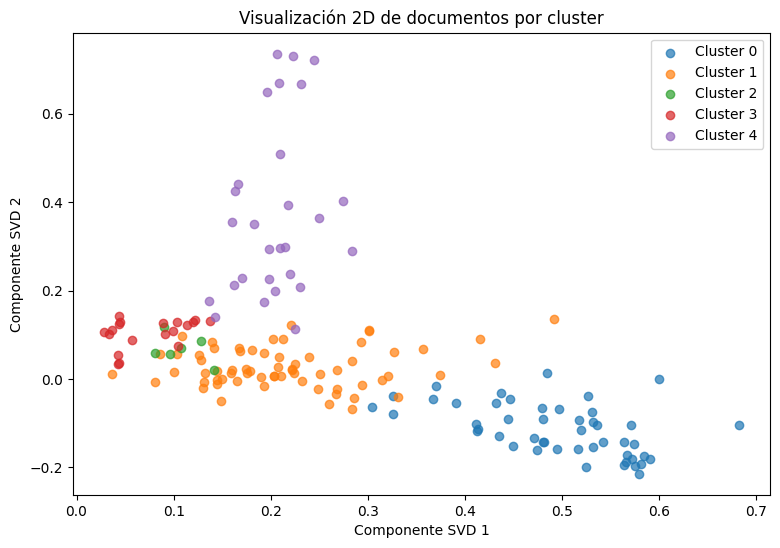

Varianza explicada aproximada por las dos componentes:
0.0664


In [23]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd.fit_transform(X_tfidf)

df_text["svd_1"] = coords_2d[:, 0]
df_text["svd_2"] = coords_2d[:, 1]

plt.figure(figsize=(9, 6))

for cluster_id in range(k_final):
    cluster_data = df_text[df_text["cluster"] == cluster_id]
    plt.scatter(
        cluster_data["svd_1"],
        cluster_data["svd_2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.title("Visualización 2D de documentos por cluster")
plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.legend()
plt.show()

print("Varianza explicada aproximada por las dos componentes:")
print(round(svd.explained_variance_ratio_.sum(), 4))

### Lectura del bloque

La visualización bidimensional permite observar de forma aproximada cómo se distribuyen los documentos según la representación TF-IDF y los clusters obtenidos.

El gráfico muestra cierta separación entre algunos grupos, especialmente en el caso de documentos con perfiles más diferenciados. Sin embargo, también se observa solapamiento entre clusters, algo esperable en un corpus histórico donde muchos documentos comparten vocabulario militar, judicial, político e institucional.

La varianza explicada por las dos componentes SVD es reducida, por lo que esta figura debe interpretarse únicamente como una ayuda visual. La interpretación principal del clustering se basa en la combinación de métricas internas, términos representativos y revisión de ejemplos documentales.

## 8. Conclusiones y limitaciones

En este mini caso se ha construido una primera agrupación no supervisada del corpus documental del 23-F usando TF-IDF y K-Means.

Después de ampliar la lista de stopwords, los términos principales de los clusters son más interpretables. Los grupos obtenidos permiten distinguir bloques relacionados con documentación judicial-militar, informes generales sobre el golpe, documentación exterior, referencias internacionales y procedimientos de justicia militar.

La elección de `k = 5` se interpreta como una solución de compromiso. Otros valores de `k` dan resultados de Silhouette ligeramente superiores, pero generan una segmentación más fragmentada. Para esta primera aproximación, cinco clusters permiten una lectura más sencilla.

La interpretación se ha hecho revisando tres elementos: términos representativos, ejemplos de documentos y tamaño de cada cluster. Esto es importante porque, al ser un análisis no supervisado, no existe una etiqueta real contra la que comparar directamente.

La visualización con SVD sirve solo como apoyo. Resume la matriz TF-IDF en dos dimensiones, por lo que no debe usarse como prueba definitiva de separación entre clusters.

Como limitación principal, K-Means obliga a asignar cada documento a un único grupo, aunque algunos documentos mezclan contenido militar, judicial, policial, político e internacional. Además, los resultados dependen bastante del preprocesamiento y de las stopwords elegidas.

Como mejora futura, podrían probarse otros enfoques como LDA, BERTopic o embeddings. Aun así, para esta versión se prioriza un método sencillo, interpretable y cercano a lo visto en clase.

## 9. Guardado de resultados

Para que el mini caso sea reutilizable desde el notebook principal de integración, se guardan las tablas y figuras principales del análisis de clustering.

Estos outputs permiten validar posteriormente el número de documentos analizados, la selección de `k`, la asignación de clusters, la interpretación manual de los grupos y la visualización bidimensional. Todas las rutas se construyen de forma relativa al repositorio.


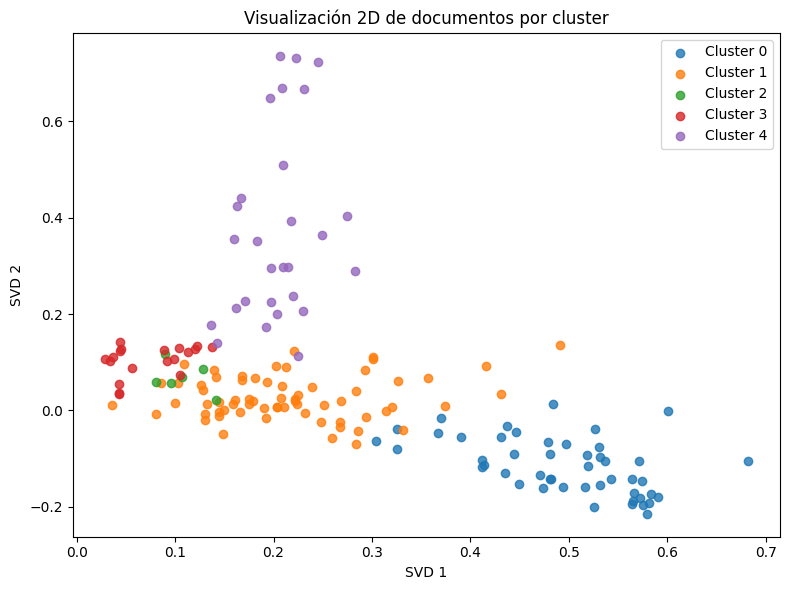

,output_type,path
0,table,outputs/tables/caso2_k_selection_metrics.csv
1,table,outputs/tables/caso2_cluster_summary.csv
2,table,outputs/tables/caso2_cluster_terms.csv
3,table,outputs/tables/caso2_cluster_interpretation.csv
4,table,outputs/tables/caso2_document_clusters.csv
5,table,outputs/tables/caso2_cluster_svd_coordinates.csv
6,figure,outputs/figures/caso2_clusters_svd.png


In [24]:
from pathlib import Path

def find_project_root(start_path=None):
    """
    Busca la raíz del repositorio subiendo desde el directorio actual hasta encontrar
    una carpeta que contenga 'notebooks' y 'data'.
    """
    current_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    
    for candidate in [current_path] + list(current_path.parents):
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    
    raise FileNotFoundError(
        "No se ha podido localizar la raíz del proyecto. "
        "Ejecuta el notebook desde la raíz del repositorio o desde la carpeta notebooks."
    )

PROJECT_ROOT = find_project_root()

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Métricas de selección de k
df_k_results.to_csv(
    OUTPUT_TABLES_DIR / "caso2_k_selection_metrics.csv",
    index=False
)

# Resumen de clusters
cluster_summary.to_csv(
    OUTPUT_TABLES_DIR / "caso2_cluster_summary.csv",
    index=False
)

# Términos representativos por cluster
df_cluster_terms.to_csv(
    OUTPUT_TABLES_DIR / "caso2_cluster_terms.csv",
    index=False
)

# Interpretación manual de clusters, si está disponible
if "df_cluster_summary" in globals():
    df_cluster_summary.to_csv(
        OUTPUT_TABLES_DIR / "caso2_cluster_interpretation.csv",
        index=False
    )

# Asignación documental a clusters
cluster_assignment_cols = [
    "doc_id",
    "title",
    "cluster",
    "text_clean_length_words",
    "moncloa_section",
    "pdf_url",
]
available_cluster_assignment_cols = [
    col for col in cluster_assignment_cols if col in df_text.columns
]

df_text[available_cluster_assignment_cols].to_csv(
    OUTPUT_TABLES_DIR / "caso2_document_clusters.csv",
    index=False
)

# Coordenadas SVD si existen
svd_cols = [
    "doc_id",
    "title",
    "cluster",
    "svd_1",
    "svd_2",
    "text_clean_length_words",
    "moncloa_section",
]
available_svd_cols = [col for col in svd_cols if col in df_text.columns]

if {"svd_1", "svd_2"}.issubset(df_text.columns):
    df_text[available_svd_cols].to_csv(
        OUTPUT_TABLES_DIR / "caso2_cluster_svd_coordinates.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    for cluster_id in sorted(df_text["cluster"].unique()):
        cluster_data = df_text[df_text["cluster"] == cluster_id]
        ax.scatter(
            cluster_data["svd_1"],
            cluster_data["svd_2"],
            label=f"Cluster {cluster_id}",
            alpha=0.8
        )

    ax.set_title("Visualización 2D de documentos por cluster")
    ax.set_xlabel("SVD 1")
    ax.set_ylabel("SVD 2")
    ax.legend()
    plt.tight_layout()

    caso2_figure_path = OUTPUT_FIGURES_DIR / "caso2_clusters_svd.png"
    plt.savefig(caso2_figure_path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    caso2_figure_path = None

saved_outputs_caso2 = pd.DataFrame({
    "output_type": [
        "table",
        "table",
        "table",
        "table",
        "table",
        "table",
        "figure",
    ],
    "path": [
        OUTPUT_TABLES_DIR / "caso2_k_selection_metrics.csv",
        OUTPUT_TABLES_DIR / "caso2_cluster_summary.csv",
        OUTPUT_TABLES_DIR / "caso2_cluster_terms.csv",
        OUTPUT_TABLES_DIR / "caso2_cluster_interpretation.csv",
        OUTPUT_TABLES_DIR / "caso2_document_clusters.csv",
        OUTPUT_TABLES_DIR / "caso2_cluster_svd_coordinates.csv",
        caso2_figure_path,
    ],
})

saved_outputs_caso2 = saved_outputs_caso2.dropna(subset=["path"])
saved_outputs_caso2["path"] = saved_outputs_caso2["path"].apply(
    lambda p: str(Path(p).relative_to(PROJECT_ROOT))
)

saved_outputs_caso2